# Audi Vehicle Listings — Exploratory Data Analysis

This notebook performs EDA and data visualization on the Audi car listings dataset (`cars_dataset.csv`), covering:

1. Data loading & cleaning
2. Summary statistics
3. Univariate analysis (price, mileage, year, engine size, mpg, tax)
4. Categorical breakdowns (model, transmission, fuel type)
5. Bivariate analysis (price vs. year / mileage / engine size / transmission / fuel type)
6. Correlation analysis
7. Outlier detection
8. Key insights

**How to use in Google Colab:** upload `cars_dataset.csv` to the Colab session (or mount Google Drive), then run all cells top to bottom.


In [1]:
# If running in Google Colab, upload the CSV first:
# from google.colab import files
# uploaded = files.upload()  # select cars_dataset.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
# In Colab, if you uploaded the file directly, the path is just the filename:
df = pd.read_csv('cars_dataset.csv')
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


## 1. Data Cleaning & Overview

The raw file has leading/trailing whitespace in the `model` column and in string values (common with this Kaggle "100,000 UK Used Car" style export). We strip it before analysis.


In [3]:
df.columns = [c.strip() for c in df.columns]
str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

print("Shape:", df.shape)
df.info()


Shape: (72435, 10)
<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 5.5 MB


/tmp/ipykernel_179/3632378739.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

Duplicate rows: 842


**Note on scope:** although the file is described as an Audi dataset, it actually contains listings for **7 makes** (`Make` column: Audi, BMW, Ford, VW, Toyota, Skoda, Hyundai) — likely because it was exported alongside other UK used-car files from the same source. The cell below filters the data down to **Audi only** so the rest of the notebook matches the stated goal. Comment out the filter if you want to reuse this notebook for cross-brand comparison — a bonus cross-brand section is included near the end.


In [5]:
print(df['Make'].value_counts())

# Keep a copy of the full multi-brand data for the bonus comparison section
df_all = df.copy()

# Filter to Audi listings only
df = df[df['Make'].str.lower() == 'audi'].reset_index(drop=True)
print("\nAudi-only shape:", df.shape)
df.head()


Make
Ford       17964
vw         15157
BMW        10781
audi       10668
toyota      6738
skoda       6267
Hyundai     4860
Name: count, dtype: int64

Audi-only shape: (10668, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,10668,26,A3,1929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,10668.0,NaN,NaN,NaN,2017.100675,2.167494,1997.0,2016.0,2017.0,2019.0,2020.0
price,10668.0,NaN,NaN,NaN,22896.685039,11714.841888,1490.0,15130.75,20200.0,27990.0,145000.0
transmission,10668,3,Manual,4369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,10668.0,NaN,NaN,NaN,24827.244001,23505.257205,1.0,5968.75,19000.0,36464.5,323000.0
fuelType,10668,3,Diesel,5577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,10668.0,NaN,NaN,NaN,126.011436,67.170294,0.0,125.0,145.0,145.0,580.0
mpg,10668.0,NaN,NaN,NaN,50.770022,12.949782,18.9,40.9,49.6,58.9,188.3
engineSize,10668.0,NaN,NaN,NaN,1.930709,0.602957,0.0,1.5,2.0,2.0,6.3
Make,10668,1,audi,10668,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Univariate Analysis


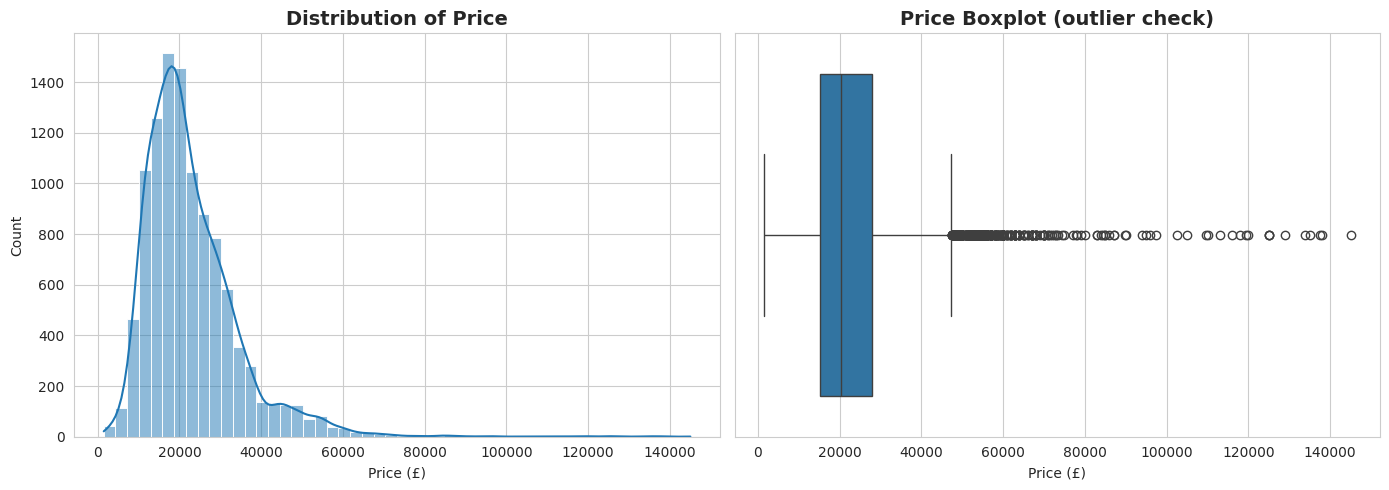

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price (£)')

sns.boxplot(x=df['price'], ax=axes[1], color='#1f77b4')
axes[1].set_title('Price Boxplot (outlier check)')
axes[1].set_xlabel('Price (£)')
plt.tight_layout()
plt.show()


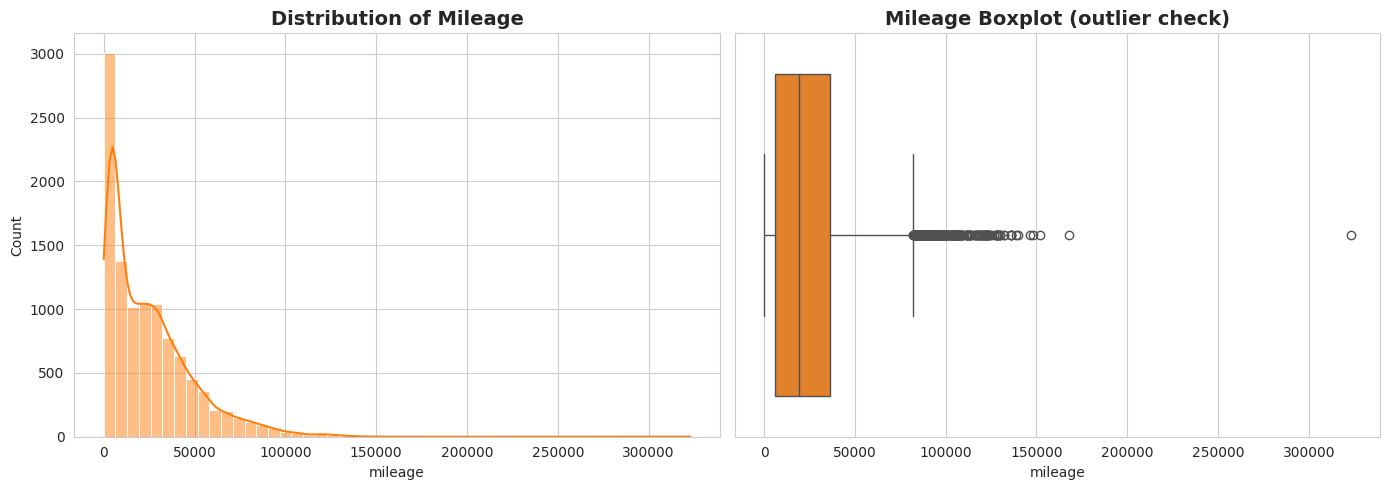

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['mileage'], bins=50, kde=True, ax=axes[0], color='#ff7f0e')
axes[0].set_title('Distribution of Mileage')

sns.boxplot(x=df['mileage'], ax=axes[1], color='#ff7f0e')
axes[1].set_title('Mileage Boxplot (outlier check)')
plt.tight_layout()
plt.show()


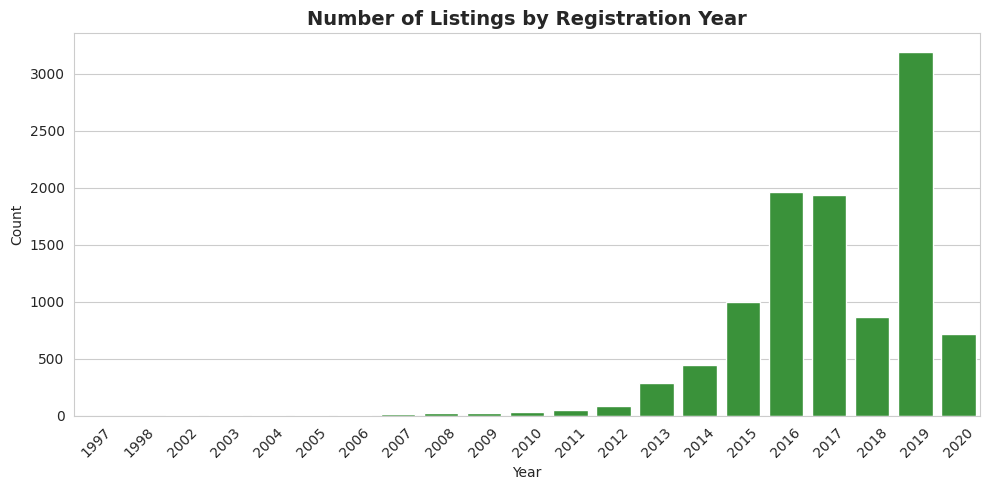

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x='year', data=df, order=sorted(df['year'].unique()), color='#2ca02c')
plt.title('Number of Listings by Registration Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


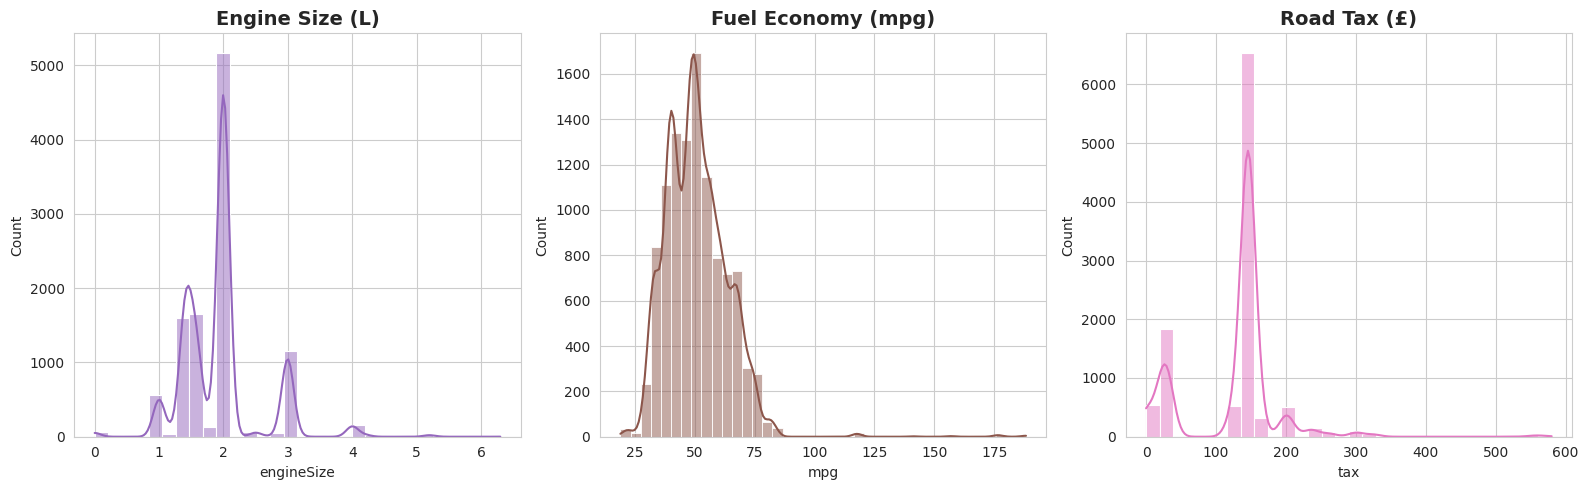

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['engineSize'], bins=30, kde=True, ax=axes[0], color='#9467bd')
axes[0].set_title('Engine Size (L)')

sns.histplot(df['mpg'], bins=40, kde=True, ax=axes[1], color='#8c564b')
axes[1].set_title('Fuel Economy (mpg)')

sns.histplot(df['tax'], bins=30, kde=True, ax=axes[2], color='#e377c2')
axes[2].set_title('Road Tax (£)')
plt.tight_layout()
plt.show()


## 3. Categorical Breakdown


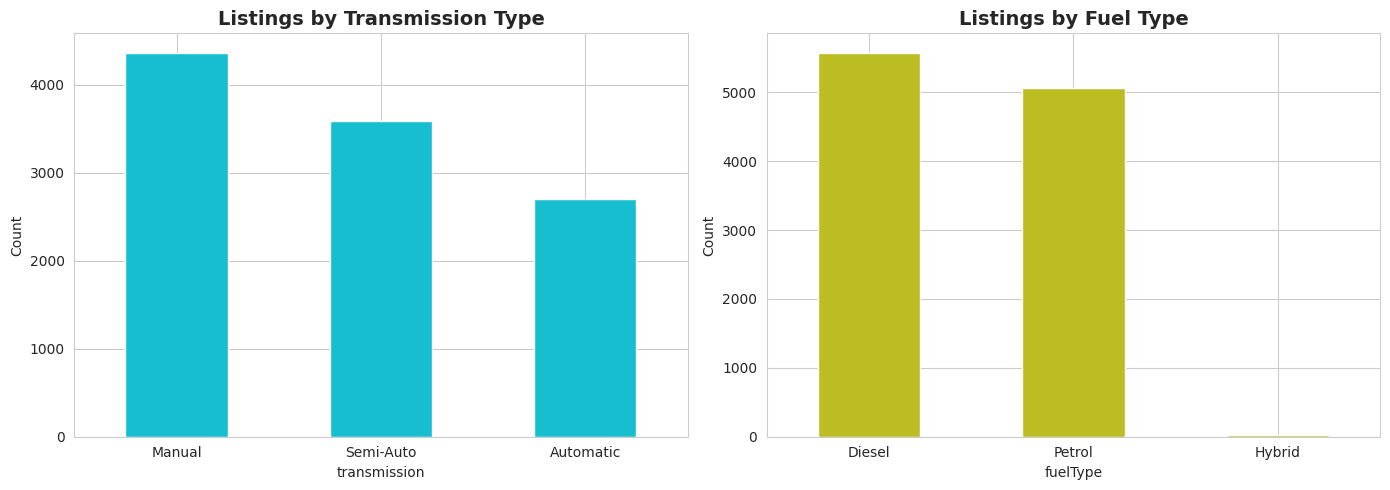

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['transmission'].value_counts().plot(kind='bar', ax=axes[0], color='#17becf')
axes[0].set_title('Listings by Transmission Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['fuelType'].value_counts().plot(kind='bar', ax=axes[1], color='#bcbd22')
axes[1].set_title('Listings by Fuel Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


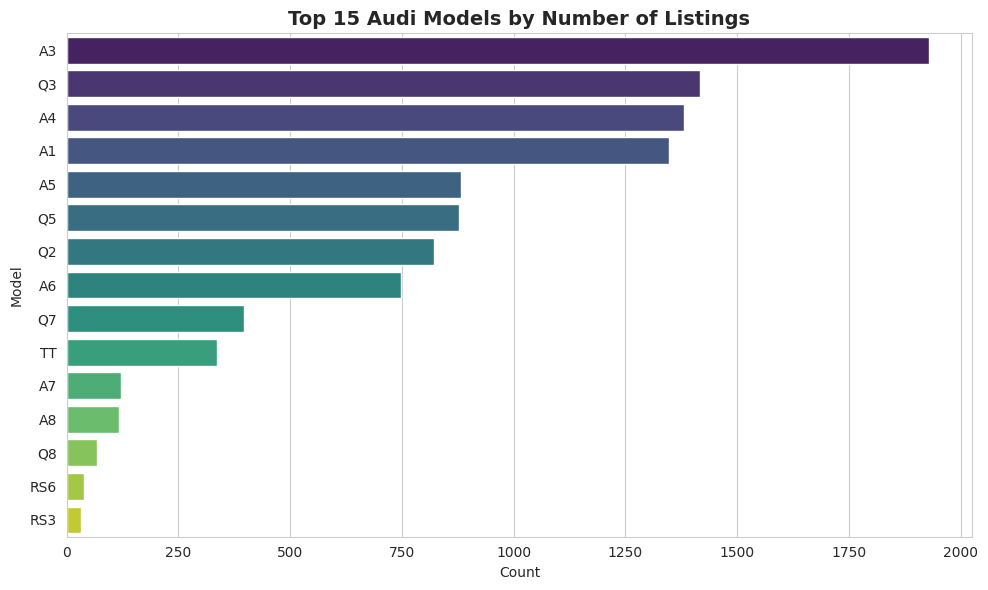

In [12]:
top_models = df['model'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.values, y=top_models.index, hue=top_models.index, legend=False, palette='viridis')
plt.title('Top 15 Audi Models by Number of Listings')
plt.xlabel('Count')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


## 4. Bivariate Analysis — Drivers of Price


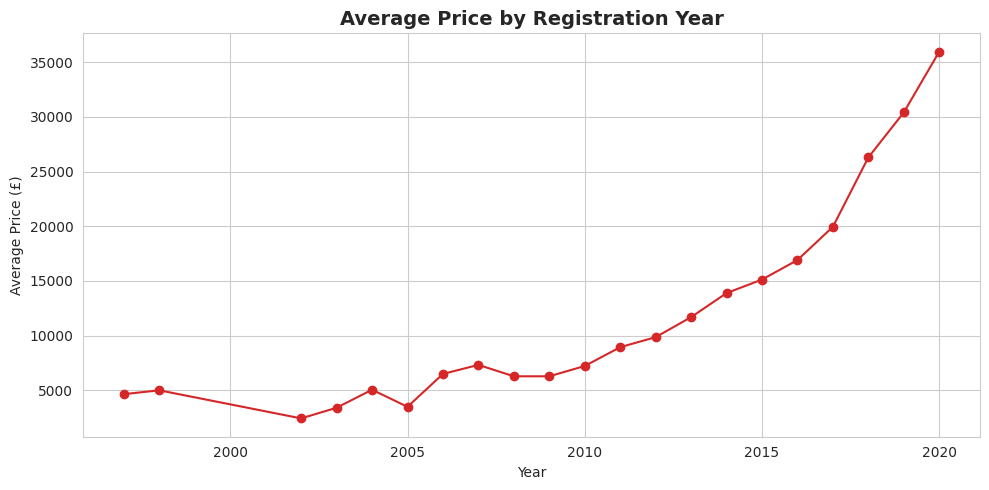

In [13]:
avg_price_by_year = df.groupby('year')['price'].mean().sort_index()
plt.figure(figsize=(10, 5))
avg_price_by_year.plot(marker='o', color='#d62728')
plt.title('Average Price by Registration Year')
plt.xlabel('Year')
plt.ylabel('Average Price (£)')
plt.tight_layout()
plt.show()


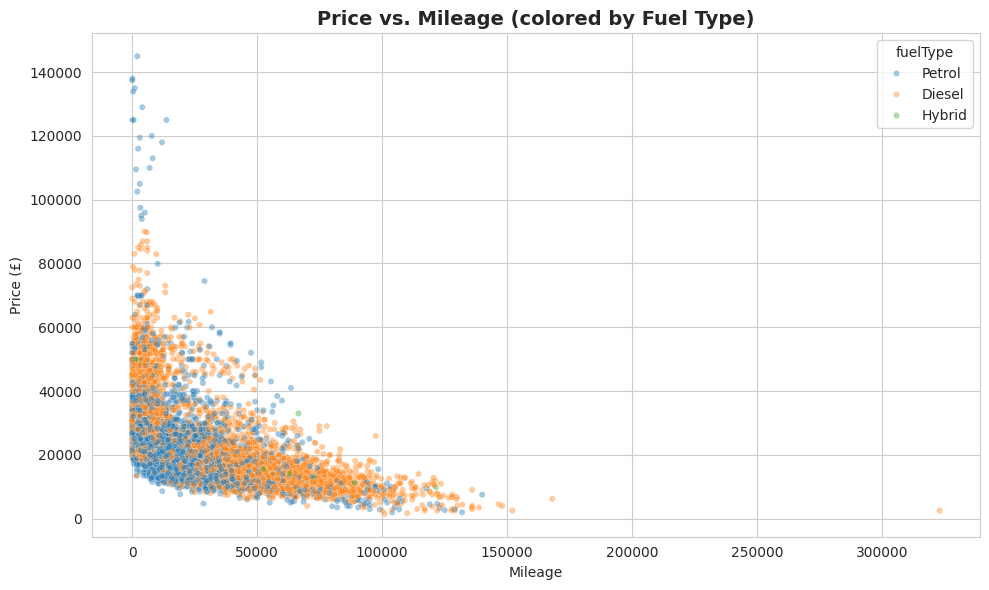

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mileage', y='price', hue='fuelType', alpha=0.4, s=20)
plt.title('Price vs. Mileage (colored by Fuel Type)')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()


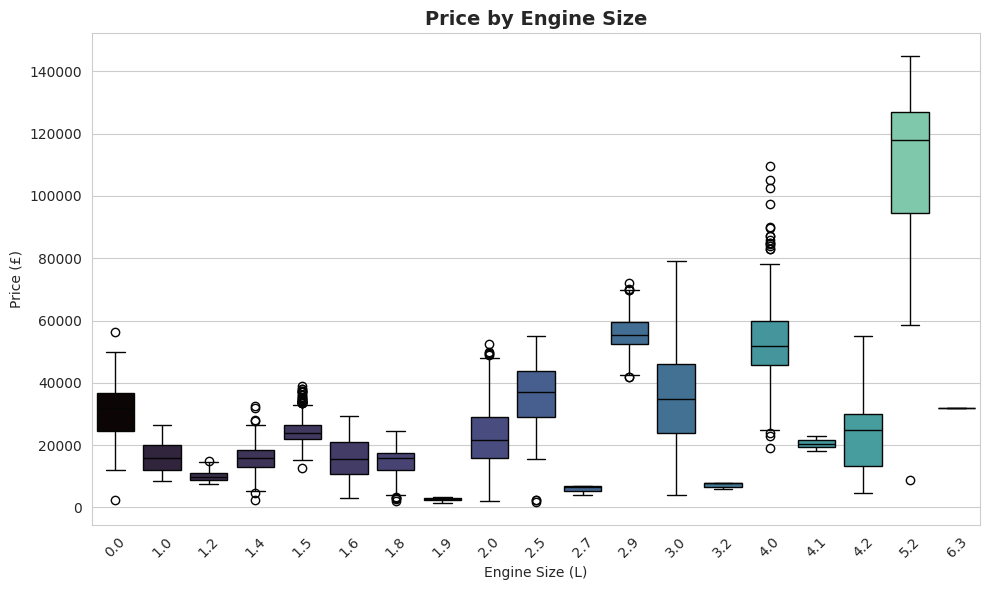

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='engineSize', y='price', hue='engineSize', legend=False, palette='mako')
plt.title('Price by Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


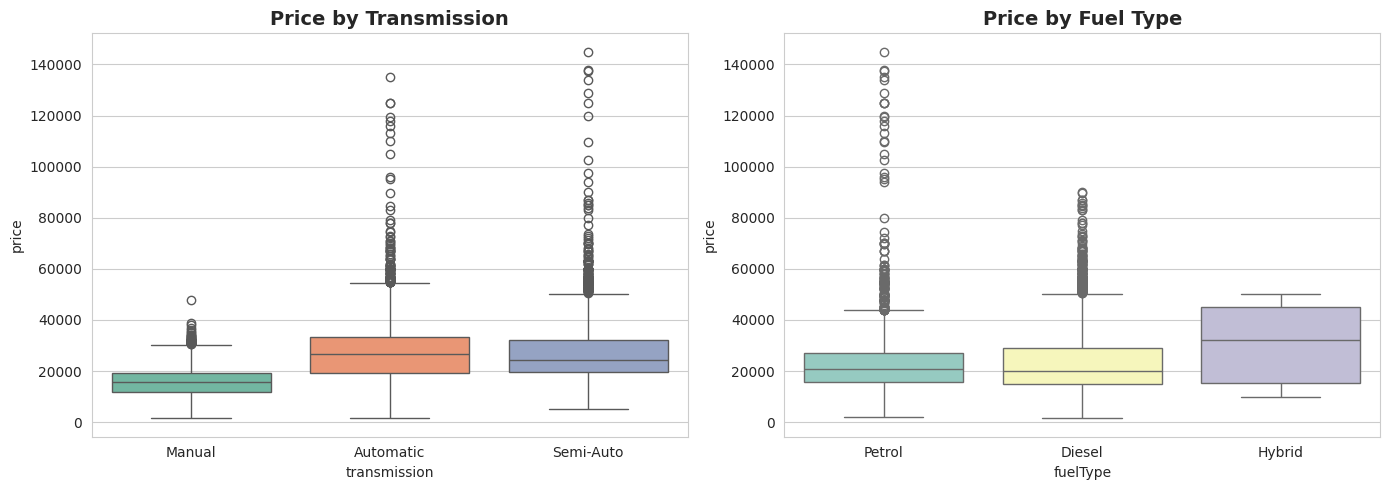

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='transmission', y='price', hue='transmission', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Price by Transmission')

sns.boxplot(data=df, x='fuelType', y='price', hue='fuelType', legend=False, ax=axes[1], palette='Set3')
axes[1].set_title('Price by Fuel Type')
plt.tight_layout()
plt.show()


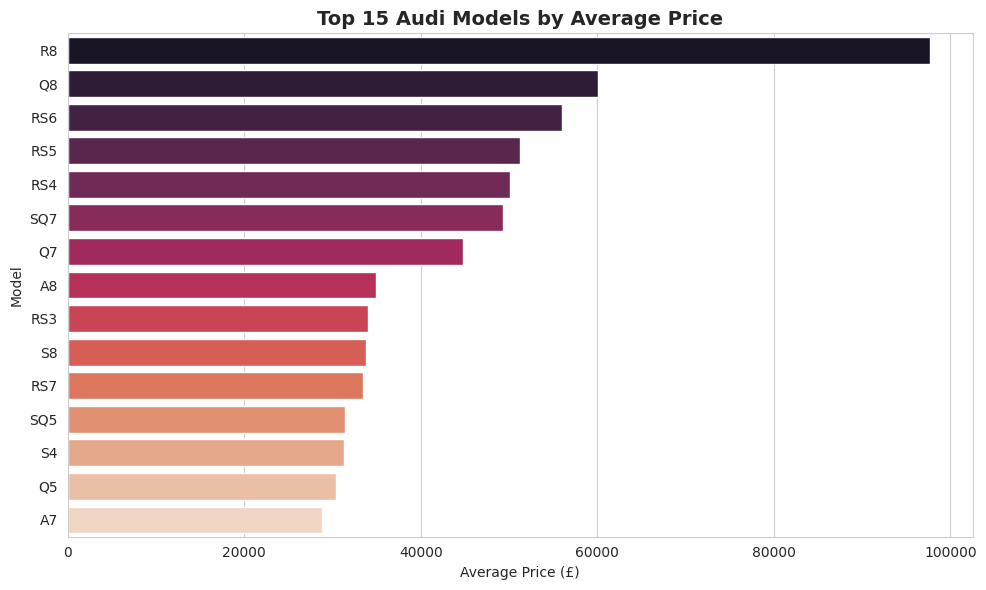

In [17]:
avg_price_by_model = df.groupby('model')['price'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_by_model.values, y=avg_price_by_model.index, hue=avg_price_by_model.index, legend=False, palette='rocket')
plt.title('Top 15 Audi Models by Average Price')
plt.xlabel('Average Price (£)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


## 5. Correlation Analysis


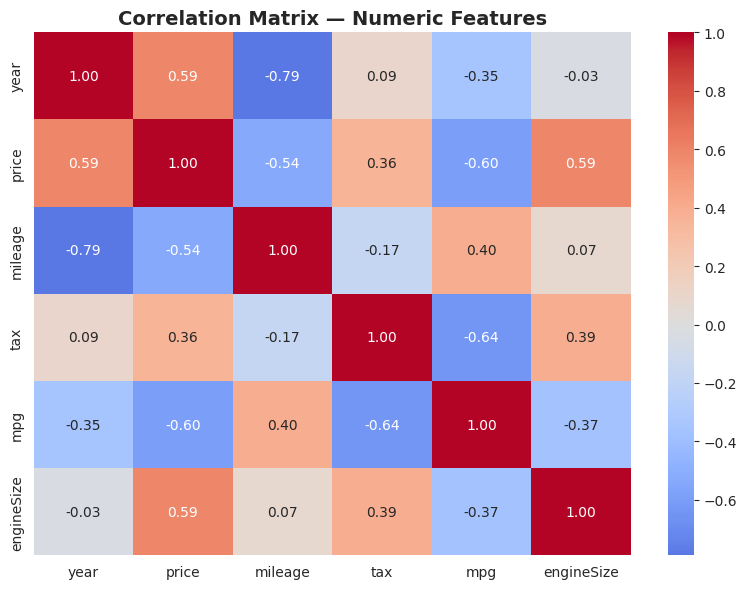

price         1.000000
year          0.592581
engineSize    0.591262
tax           0.356157
mileage      -0.535357
mpg          -0.600334
Name: price, dtype: float64

In [18]:
numeric_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

corr['price'].sort_values(ascending=False)


## 6. Outlier Detection (IQR method on Price)


In [19]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Price IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Number of price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of Audi listings)")
outliers[['model', 'year', 'price', 'mileage', 'fuelType']].sort_values('price', ascending=False).head(10)


Price IQR bounds: [-4,158, 47,279]
Number of price outliers: 443 (4.2% of Audi listings)


,model,year,price,mileage,fuelType
4783,R8,2020,145000,2000,Petrol
2255,R8,2020,137995,70,Petrol
4179,R8,2019,137500,10,Petrol
3367,R8,2019,135000,1000,Petrol
5459,R8,2020,133900,333,Petrol
1646,R8,2019,129000,4000,Petrol
10468,R8,2019,125000,13663,Petrol
4925,R8,2019,125000,500,Petrol
3359,R8,2019,125000,100,Petrol
7445,R8,2019,119995,7800,Petrol


## 7. Bonus — How Audi Compares to Other Brands in the File

The uploaded file also contains BMW, Ford, VW, Toyota, Skoda, and Hyundai listings. This section uses `df_all` (unfiltered) purely as an extra point of comparison.


In [20]:
df_all.columns = [c.strip() for c in df_all.columns]
for c in df_all.select_dtypes(include='object').columns:
    df_all[c] = df_all[c].astype(str).str.strip()

brand_summary = df_all.groupby('Make').agg(
    listings=('price', 'size'),
    avg_price=('price', 'mean'),
    avg_mileage=('mileage', 'mean'),
    avg_mpg=('mpg', 'mean')
).sort_values('avg_price', ascending=False).round(0)
brand_summary


/tmp/ipykernel_179/3776275409.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_all.select_dtypes(include='object').columns:


,listings,avg_price,avg_mileage,avg_mpg
Make,,,,
audi,10668,22897.0,24827.0,51.0
BMW,10781,22733.0,25497.0,56.0
vw,15157,16839.0,22093.0,54.0
skoda,6267,14275.0,20118.0,57.0
Hyundai,4860,12750.0,21486.0,54.0
toyota,6738,12522.0,22857.0,63.0
Ford,17964,12280.0,23362.0,58.0


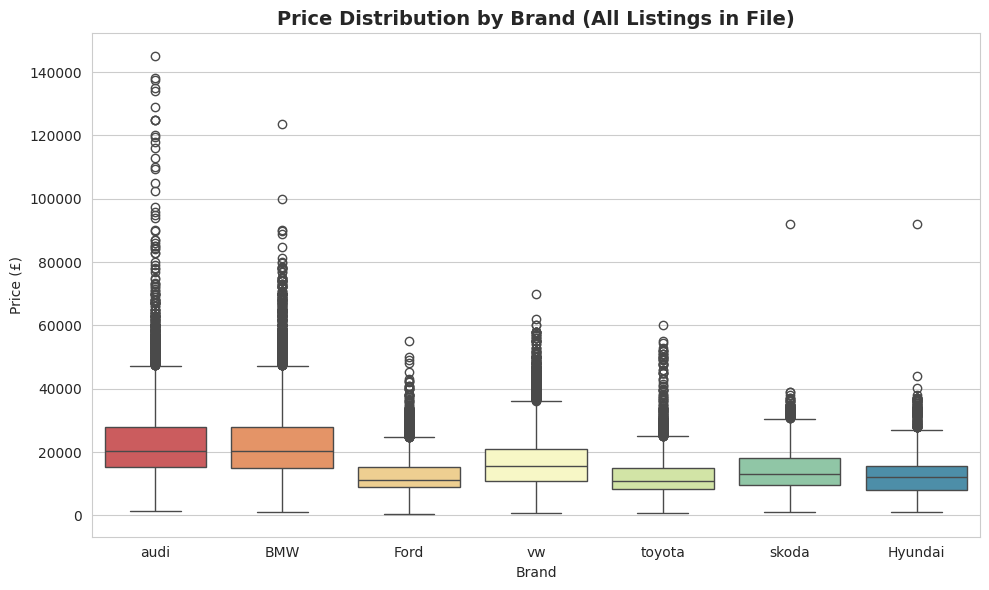

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all, x='Make', y='price', hue='Make', legend=False, palette='Spectral')
plt.title('Price Distribution by Brand (All Listings in File)')
plt.xlabel('Brand')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()


## 8. Key Insights

- **Price is right-skewed**: most Audi listings sit in the £10k–£30k range, with a long tail of high-end models (RS/S-line, R8) pulling the mean above the median.
- **Mileage and price are negatively correlated** — as expected, higher-mileage cars sell for less, though the relationship flattens out for very high mileage.
- **Engine size and price move together**: larger-engine Audis (RS/S/Q7/Q8/A8) command a clear price premium over smaller-engine A1/A3/Q2 models.
- **Newer registration years fetch higher average prices**, but the increase is not perfectly linear — certain older models with strong residual value (e.g., R8, TT) buck the trend.
- **Transmission and fuel type matter less than engine size or mileage**, though automatics and diesels trend slightly higher on average within this dataset.
- **A3, Q3, A4, and A1 dominate volume** (most listings), while **RS/S-badged and Q7/Q8/A8 models command the highest average prices** despite far lower listing counts.
- A handful of very high-value outliers (RS6, RS7, R8, S8) skew the top end of the price distribution and are worth excluding or modeling separately in any price-prediction pipeline.

**Suggested next steps for modeling:** one-hot encode `model`, `transmission`, and `fuelType`; log-transform `price` and `mileage` to reduce skew; consider removing or capping the top 1–2% price outliers before training a regression model.
